In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle

import os,sys
from pathlib import Path
current_dir = Path(os.getcwd()).resolve()
project_root = current_dir.parent
functions_path = project_root / "functions"
sys.path.append(str(functions_path))

import models_circular as models
import multiGP



# Radial velocity plots

In [2]:
data_dir = "/home/ymascolo/Desktop/github/datasets" # path datsets

# import datasets
with open(os.path.join(data_dir, "processed_data/LHS6050b_global_data.pkl"), "rb") as f:
    data_loaded = pickle.load(f)

espresso_data = data_loaded["espresso_data"]

t = espresso_data["time"]
rv = espresso_data["rv"]
rv_err = espresso_data["rv_err"]
fwhm = espresso_data["fwhm"]
fwhm_err = espresso_data["fwhm_err"]
bis = espresso_data["bis"]
bis_err = espresso_data["bis_err"]
asym = espresso_data["asym"]
asym_err = espresso_data["asym_err"]

### Phase folded plot

In [3]:
# JSON file with the best fit parameters from the global fit
# ===================
with open(os.path.join(data_dir,"best_fit_results.json")) as f:
    data = json.load(f)

fp = data['fitted_parameters']

theta_best = [
    fp['t_0']['median'],    
    fp['P']['median'],
    fp['krv']['median'],    
    fp['gamma']['median'],   
    fp['lam']['median'],
    fp['P_{rot}']['median'],
    fp['w']['median'],
    fp['RV_{scale}']['median'],
    fp['fwhm_{scale}']['median'],
    fp['bis_{scale}']['median'],
    fp['asym_{scale}']['median'],
    fp['RV_{dGdt\\,scale}']['median'],
    fp['FWHM_{dGdt \\,scale}']['median'],
    fp['asym_{dGdt \\,scale}']['median'],
    fp['rv_{jitter}']['median'],
    fp['fwhm_{jitter}']['median'],
    fp['bis_{jitter}']['median'],
    fp['asym_{jitter}']['median'],
    
]

t0, per = theta_best[0], theta_best[1]
krv, gamma = theta_best[2], theta_best[3] 
lam, prot, w = theta_best[4], theta_best[5], theta_best[6] 
RV_scale, fwhm_scale, bis_scale = theta_best[7], theta_best[8], theta_best[9] 
asym_scale = theta_best[10] 
RV_dGdt_scale   = theta_best[11] 
fwhm_dGdt_scale = theta_best[12] 
asym_dGdt_scale = theta_best[13] 
rv_jitter   = theta_best[14] 
fwhm_jitter = theta_best[15] 
bis_jitter  = theta_best[16] 
asym_jitter = theta_best[17] 

In [4]:
# Gaussian Process model
# =========================

# Hyperparameters GP
hp = multiGP.QPHyperParams(amp=1, lam=lam, P=prot, w=w)
A = np.array([RV_scale, fwhm_scale, bis_scale, asym_scale])
B = np.array([RV_dGdt_scale, fwhm_dGdt_scale, 0.0, asym_dGdt_scale])
jitter = np.array([rv_jitter, fwhm_jitter, bis_jitter, asym_jitter])

# data list
t_list   = [t, t, t, t]
r_list   = [rv - models.planetmodel(theta_best, t), fwhm, bis, asym]
err_list = [rv_err, fwhm_err, bis_err, asym_err]
t_rv = t

# Grid 
tgrid = np.linspace(t_rv.min(), t_rv.max(), 2000)
rvmodel_grid = models.planetmodel(theta_best, tgrid)



# -----------GP prediction on grid----------

t_star_list = [tgrid, tgrid, tgrid, tgrid]

mu_list, sig_list = multiGP.gp_predict_multidim(
    t_list, r_list, err_list,
    t_star_list=t_star_list,
    A=A,
    B=B,
    hp=hp,
    jitter=jitter,
)

mu_rv_grid   = mu_list[0]
mu_fwhm_grid   = mu_list[1]
mu_bis_grid   = mu_list[2]
asym_bis_grid   = mu_list[3]


# ---------------GP prediction on observed time------------

mu_obs_list, _ = multiGP.gp_predict_multidim(
    t_list, r_list, err_list,
    t_star_list=t_list,
    A=A,
    B=B,
    hp=hp,
    jitter=jitter,
)

mu_rv_obs = mu_obs_list[0]

In [5]:
# Bin function
# ====================

def phase_bin(phase, rv, rv_err):

    phase = np.asarray(phase) % 1.0
    rv = np.asarray(rv)
    rv_err = np.asarray(rv_err)
    
    # N bins with fixed spacing: 1.0 / 10 = 0.1 phase width per bin.
    n_bins = 10
    
    # Create equal-spaced bin edges
    bins = np.linspace(0, 1, n_bins + 1)
    digitized = np.digitize(phase, bins) - 1

    phase_binned, rv_binned, err_binned = [], [], []

    for i in range(n_bins):
        mask = digitized == i
        n_p = np.sum(mask)

        if n_p > 0:
            p_chunk = phase[mask]
            rv_chunk = rv[mask]
            err_chunk = rv_err[mask]

            # Weighted Mean RV
            w = 1.0 / err_chunk**2
            rv_mean = np.sum(w * rv_chunk) / np.sum(w)
            
            # Weighted Phase Center 
            phase_center = np.sum(w * p_chunk) / np.sum(w)
            
            # Standard Error (The 68% confidence interval of the mean)
            if n_p > 1:
                std_error = np.std(rv_chunk) / np.sqrt(n_p)
                # Fallback if all points in bin are identical
                if std_error == 0:
                    std_error = np.sqrt(1.0 / np.sum(w))
            else:
                # Fallback for 1 point: use the instrumental error
                std_error = err_chunk[0]

            phase_binned.append(phase_center)
            rv_binned.append(rv_mean)
            err_binned.append(std_error)

    return np.array(phase_binned), np.array(rv_binned), np.array(err_binned)

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


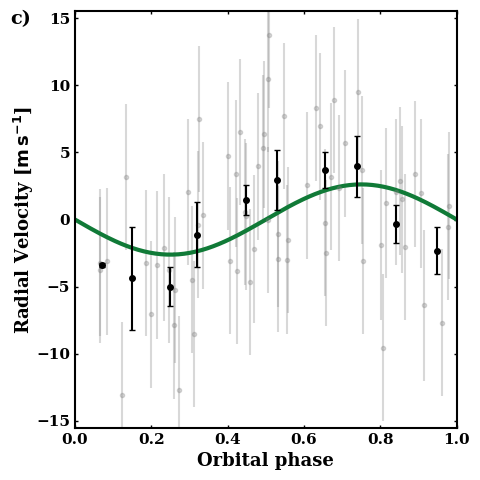

In [6]:
# Plot RV vs phase 
# ------------------------
colors = sns.color_palette("Greens", 10)  

fig = plt.figure(figsize=(5,5))
plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    'font.weight': 'bold',        # Bold standard text
    'axes.labelweight': 'bold',   # Bold X and Y labels
    'axes.titleweight': 'bold',   # Bold Title
    'figure.titleweight': 'bold',  # Bold Figure title
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    'mathtext.fontset': 'custom',
    'mathtext.bf': 'sans:bold',
    'mathtext.rm': 'sans',
})

phase_grid = np.linspace(0,1,200)
cadence_days = 50 / (24 * 60)   # days
bin_width = cadence_days / per
sinusoid = -krv * np.sin(2 * np.pi * phase_grid) 

phase = ((t_rv - t0) / per) % 1
ph_bin, rv_bin, err_bin = phase_bin(phase, rv - mu_rv_obs, np.sqrt(rv_err**2 + rv_jitter**2))

plt.errorbar(phase, (rv - mu_rv_obs-gamma)*1e3, yerr=(np.sqrt(rv_err**2 + rv_jitter**2))*1e3, fmt='.', alpha=0.3, color='grey', label='Data')
plt.errorbar(ph_bin, (rv_bin-gamma)*1e3, yerr=err_bin*1e3, fmt="o", color='k', ms=4, label='Data binned', zorder=4, capsize=2)
plt.plot(phase_grid, sinusoid*1e3, color=colors[8], lw=3, label='Sinusoidal')

# plt.text(0.05,0.8,"$\mathrm{K_{RV}=3.29^{+1.00}_{-0.97}}$ m/s",fontsize=12,color='k',transform=plt.gca().transAxes)
plt.xlim(0.0, 1)
plt.ylim(-15.5, 15.5)
plt.xlabel("Orbital phase")
plt.ylabel("Radial Velocity [$\mathrm{m\,s^{-1}}$]", labelpad=0)
# plt.legend(loc='upper left', ncol=1, fontsize=12)

ax = plt.gca()
for side in ['top', 'bottom', 'left', 'right']:
    ax.spines[side].set_linewidth(1.5)
    ax.spines[side].set_edgecolor('black')
ax.grid(False)
ax.set_facecolor('white')
ax.tick_params(axis='both', which='major', labelsize=11,
               width=1, length=2, color='black', direction='in', top=True, right=True)
ax.text(-0.17, 0.97, 'c)', fontsize=14, transform=ax.transAxes)

plt.tight_layout()
#plt.savefig('RV.pdf', dpi=300)
plt.show()


### Recovery injection and distributions

In [7]:
# import posterior distributions from global fit outputs file 
file_path = os.path.join(data_dir, "mcmc_results.npz")
data = np.load(file_path)

full_chain = data['chain'] 
samples = full_chain.reshape(-1, full_chain.shape[-1])

# posteriors used to derive planetary mass distribution
per =samples[:, 1] 
rp = samples[:, 2]
b = samples[:, 3]
mstar = samples[:, 4]
rstar = samples[:, 5]
krv = samples[:, 18]

a = ((per / 365.25)**(2/3) * mstar**(1/3) * 215.032) / rstar

cosi = b / a
inc = np.degrees(np.arccos(cosi))
sini = np.sin(np.radians(inc))

G = 6.67430e-11
M_sun = 1.9885e30
day2sec = 86400
M_earth = 5.972e24

M_star = mstar * M_sun
per_sec = per * day2sec

Mp = (krv * (M_star**(2/3)) * ((per_sec / (2*np.pi*G))**(1/3))) / sini

# mass distribution
Mpe = (Mp / M_earth)*1e3

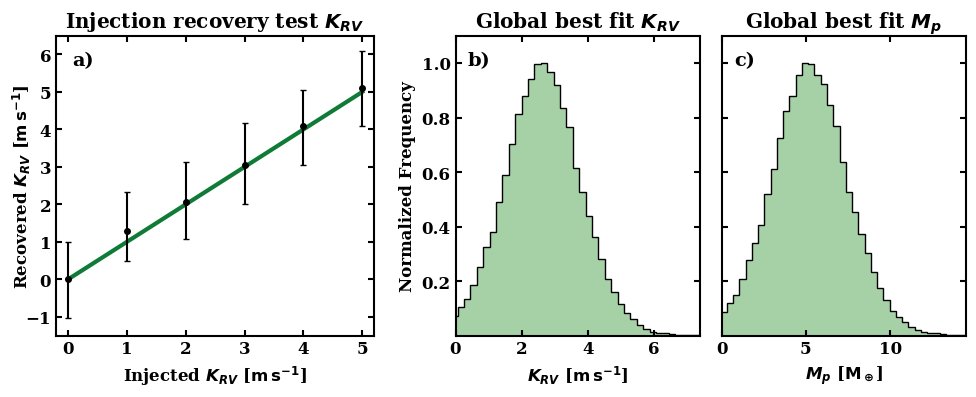

In [8]:
# normalised bins function 
def get_weights(data, bins):
    counts, _ = np.histogram(data, bins=bins)
    return np.ones_like(data) / counts.max()

samples_to_plot = np.vstack([krv * 1e3, Mpe]).T


# -------subplots--------
fig, axes = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw={'width_ratios': [1.3, 1, 1]})

plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    'font.weight': 'bold',        # Bold standard text
    'axes.labelweight': 'bold',   # Bold X and Y labels
    'axes.titleweight': 'bold',   # Bold Title
    'figure.titleweight': 'bold',  # Bold Figure title
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    'mathtext.fontset': 'custom',
    'mathtext.bf': 'sans:bold',
    'mathtext.rm': 'sans',
})

for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=4)
 
    for side in ['top', 'bottom', 'left', 'right']:
        ax.spines[side].set_linewidth(1.5)
        ax.spines[side].set_edgecolor('black')
        ax.grid(False)

# --------Plot 1: recovery injection---------
x=[0, 1,2,3,4,5]
y=[1.5272306621534084e-02, 1.2949490858931885, 2.069677991825637, 3.0593953758004068, 4.081066190606978, 5.095653913460353]
yerr=[[1.0431336642291573, 0.7906748817357404, 0.9857045204023965, 1.0481467655995445, 1.0188887814882894, 1.0057888444378717],\
      [0.9951664264699965, 1.0300185548362123, 1.0561511513104858, 1.1131615797780594, 0.9598066417076641, 0.9966910396268774]]
r=x
axes[0].errorbar(x, y, yerr=yerr,fmt="o", color='k', ms=4, zorder=4, capsize=2)


axes[0].plot(x, r, color=colors[8], lw=3)

axes[0].set_xlabel(r'Injected ${K_{RV}}$ [$\mathbf{m\,s^{-1}}$]', fontsize=12)
axes[0].set_ylabel(r'Recovered ${K_{RV}}$ [$\mathbf{m\,s^{-1}}$]', fontsize=12, labelpad=-5)
axes[0].set_xlim(-0.2, 5.2)
axes[0].set_ylim(-1.5, 6.5)
axes[0].set_title(r'Injection recovery test ${K_{RV}}$')

axes[0].text(0.05, 0.9, 'a)', fontsize=14, transform=axes[0].transAxes)


bins_n = 130
# -------Plot 2: krv --------
weights0 = get_weights(samples_to_plot[:, 0], bins_n)
axes[1].hist(samples_to_plot[:, 0], bins=bins_n, weights=weights0, 
       color='forestgreen', alpha=0.4, histtype='stepfilled', edgecolor='none')
axes[1].hist(samples_to_plot[:, 0], bins=bins_n, weights=weights0, 
             color='black', histtype='step', lw=1)

axes[1].set_xlabel(r'${K_{RV}}$ [$\mathbf{m\,s^{-1}}$]', fontsize=12)
axes[1].set_ylabel('Normalized Frequency',  fontsize=12)
axes[1].set_xlim(0, 7.4)
axes[1].set_title(r'Global best fit ${K_{RV}}$')

axes[1].set_ylim(0.001, 1.1)

axes[1].text(0.05, 0.9, 'b)', fontsize=14, transform=axes[1].transAxes)

# ---------Plot 3: Mpe-----------
weights1 = get_weights(samples_to_plot[:, 1], bins_n)
axes[2].sharey(axes[1])
plt.setp(axes[2].get_yticklabels(), visible=False)

axes[2].hist(samples_to_plot[:, 1], bins=bins_n, weights=weights1, 
             color='forestgreen', alpha=0.4, histtype='stepfilled', edgecolor='none')
axes[2].hist(samples_to_plot[:, 1], bins=bins_n, weights=weights1, 
             color='black', histtype='step', lw=1)
axes[2].set_title(r'Global best fit $M_p$')
axes[2].set_xlabel(r'$M_p$ [$\mathbf{M_\oplus}$]', fontsize=12)
axes[2].set_xlim(0, 14.5)
axes[2].text(0.05, 0.9, 'c)', fontsize=14, transform=axes[2].transAxes)

plt.subplots_adjust(wspace=0.08, left=0.1, right=0.95, bottom=0.15, top=0.9)

pos2 = axes[1].get_position()
axes[1].set_position([pos2.x0 + 0.06, pos2.y0, pos2.width, pos2.height])
pos2 = axes[2].get_position()
axes[2].set_position([pos2.x0 + 0.06, pos2.y0, pos2.width, pos2.height])

#plt.savefig('hist.pdf', dpi=300, bbox_inches='tight')
plt.show()